# Lab Group B – Diabetes Classification

The [Pima Indians Diabetes dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) contains 768 patient records.  
Each record has 8 clinical features and a binary target (`Outcome`):

| Feature | Description |
|---|---|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-hour serum insulin (mu U/ml) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes pedigree function |
| Age | Age (years) |
| **Outcome** | 1 = diabetic, 0 = not diabetic |

**Goal:** train and compare multiple classifiers to predict diabetes onset, select the best, and report final test-set performance.

## Section 1 – Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

## Section 2 – Load & Explore Data

In [2]:
df = pd.read_csv("diabetes.csv")
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class balance: {0: 0.651, 1: 0.349}


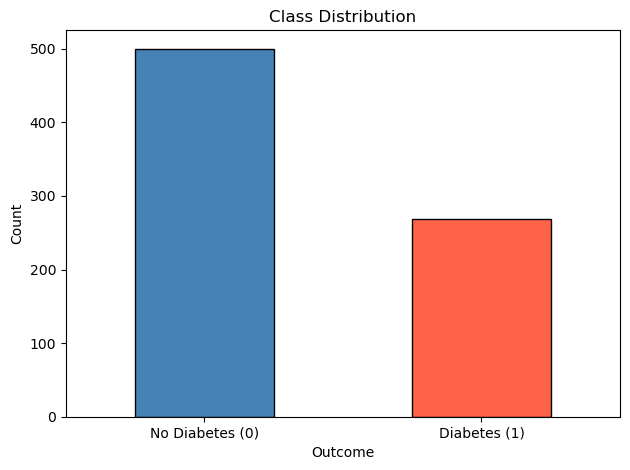

In [5]:
# Check class distribution
print("Class distribution:")
print(df["Outcome"].value_counts())
print(f"\nClass balance: {df['Outcome'].value_counts(normalize=True).round(3).to_dict()}")

df["Outcome"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.xticks([0, 1], ["No Diabetes (0)", "Diabetes (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [6]:
# Several features use 0 as a proxy for missing values (physiologically impossible)
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Zero counts in features that cannot be 0:")
print((df[zero_cols] == 0).sum())

Zero counts in features that cannot be 0:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [7]:
# Replace 0s with column median (imputation)
df_clean = df.copy()
for col in zero_cols:
    median_val = df_clean.loc[df_clean[col] != 0, col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print("After imputation – zeros remaining:")
print((df_clean[zero_cols] == 0).sum())

After imputation – zeros remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


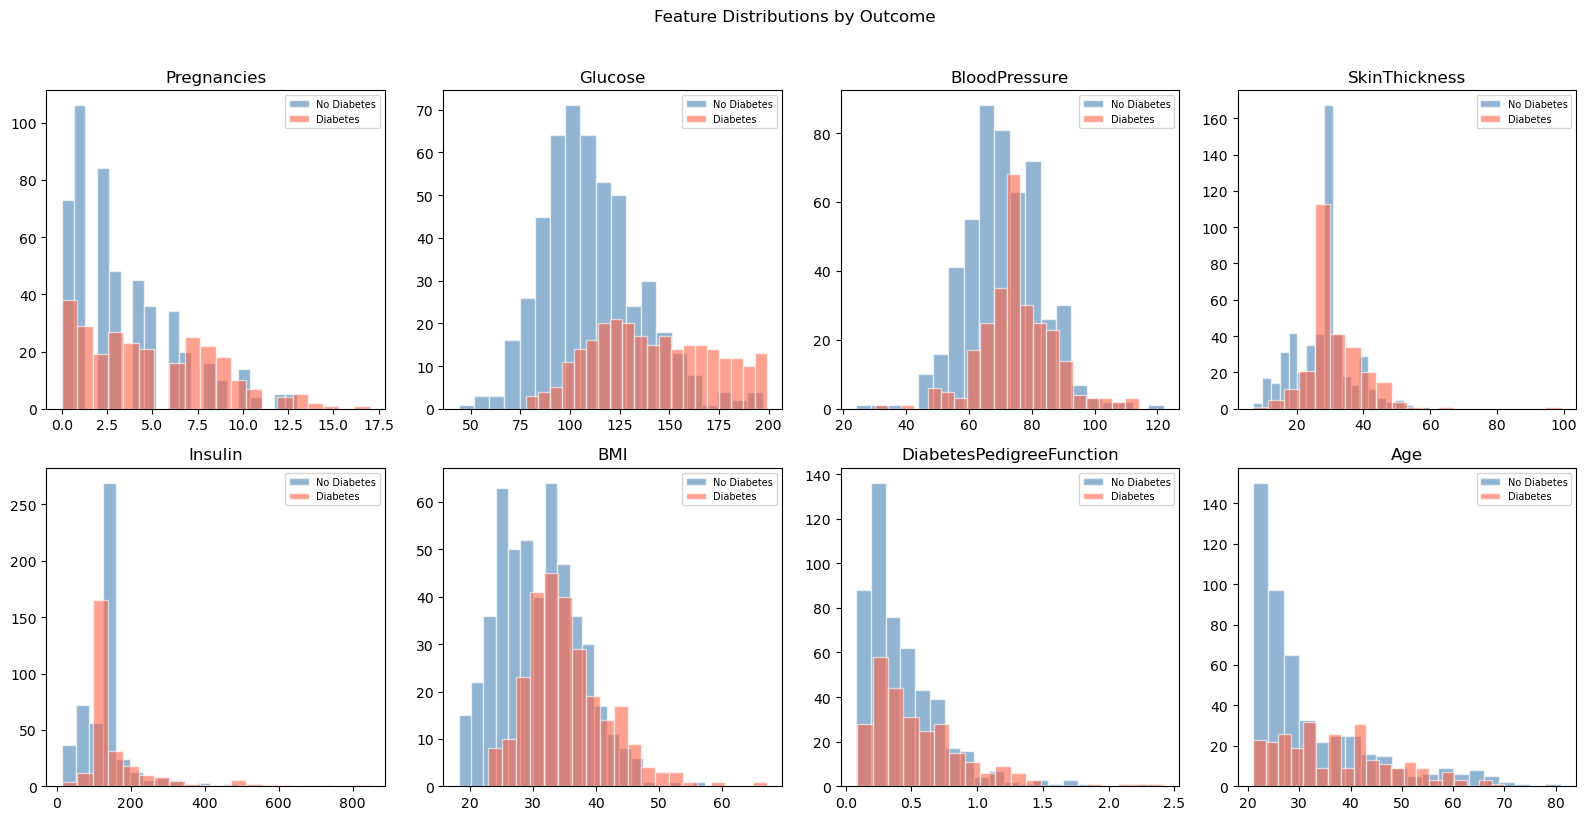

In [8]:
# Feature distributions by class
feature_cols = [c for c in df_clean.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, feature_cols):
    for outcome, color, label in [(0, "steelblue", "No Diabetes"), (1, "tomato", "Diabetes")]:
        ax.hist(df_clean.loc[df_clean["Outcome"] == outcome, col],
                bins=20, alpha=0.6, color=color, label=label, edgecolor="white")
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle("Feature Distributions by Outcome", y=1.02)
plt.tight_layout()
plt.show()

## Section 3 – Prepare Features & Split Data

We separate features (`X`) and target (`y`), scale with `StandardScaler`, then split:

- **60 %** training  
- **20 %** validation (hyperparameter tuning)  
- **20 %** test (final evaluation only)

In [9]:
X = df_clean[feature_cols].values
y = df_clean["Outcome"].values

# First hold out 20 % as the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1138, stratify=y
)

# Split the remainder 75/25 → 60 % train, 20 % validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1138, stratify=y_temp
)

print(f"Train   : {X_train.shape}")
print(f"Valid   : {X_valid.shape}")
print(f"Test    : {X_test.shape}")

Train   : (460, 8)
Valid   : (154, 8)
Test    : (154, 8)


In [10]:
# Scale features (fit only on training data to avoid data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test  = scaler.transform(X_test)

## Section 4 – Support Vector Machine (SVC)

In [11]:
# Baseline SVC with linear kernel
svc_base = SVC(kernel="linear", random_state=1138)
svc_base.fit(X_train, y_train)
print(f"Train accuracy : {svc_base.score(X_train, y_train):.4f}")
print(f"Valid accuracy : {svc_base.score(X_valid, y_valid):.4f}")

Train accuracy : 0.7630
Valid accuracy : 0.7922


In [12]:
y_valid_pred_svc = svc_base.predict(X_valid)
print(confusion_matrix(y_valid, y_valid_pred_svc))
print(classification_report(y_valid, y_valid_pred_svc))

[[91  9]
 [23 31]]
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       100
           1       0.78      0.57      0.66        54

    accuracy                           0.79       154
   macro avg       0.79      0.74      0.76       154
weighted avg       0.79      0.79      0.78       154



In [13]:
# Grid search over C and kernel
param_grid_svc = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"]
}
grid_svc = GridSearchCV(SVC(random_state=1138), param_grid=param_grid_svc, cv=5, verbose=1)
grid_svc.fit(X_train, y_train)
print("Best params :", grid_svc.best_params_)
print(f"CV best score  : {grid_svc.best_score_:.4f}")
print(f"Valid accuracy : {grid_svc.score(X_valid, y_valid):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'C': 0.1, 'kernel': 'linear'}
CV best score  : 0.7652
Valid accuracy : 0.7987


## Section 5 – Random Forest Classifier

In [14]:
# Baseline Random Forest
rf_base = RandomForestClassifier(random_state=1138)
rf_base.fit(X_train, y_train)
print(f"Train accuracy : {rf_base.score(X_train, y_train):.4f}")
print(f"Valid accuracy : {rf_base.score(X_valid, y_valid):.4f}")

Train accuracy : 1.0000
Valid accuracy : 0.7727


In [15]:
# Grid search over n_estimators and max_depth
param_grid_rf = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [5, 10, 20, None]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=1138),
                       param_grid=param_grid_rf, cv=5, verbose=1)
grid_rf.fit(X_train, y_train)
print("Best params :", grid_rf.best_params_)
print(f"CV best score  : {grid_rf.best_score_:.4f}")
print(f"Valid accuracy : {grid_rf.score(X_valid, y_valid):.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'max_depth': 10, 'n_estimators': 200}
CV best score  : 0.7630
Valid accuracy : 0.7987


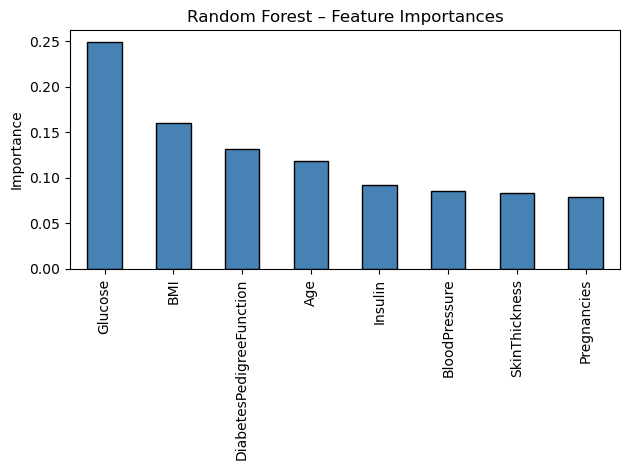

In [16]:
# Feature importances from the best RF model
importances = grid_rf.best_estimator_.feature_importances_
feat_df = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
feat_df.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Random Forest – Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Section 6 – k-Nearest Neighbours (KNN)

In [17]:
# Baseline KNN (k=5)
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
print(f"Train accuracy : {knn_base.score(X_train, y_train):.4f}")
print(f"Valid accuracy : {knn_base.score(X_valid, y_valid):.4f}")

Train accuracy : 0.8152
Valid accuracy : 0.7987


In [18]:
# Grid search over k
param_grid_knn = {"n_neighbors": range(1, 31)}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid_knn, cv=5, verbose=1)
grid_knn.fit(X_train, y_train)
print("Best params :", grid_knn.best_params_)
print(f"CV best score  : {grid_knn.best_score_:.4f}")
print(f"Valid accuracy : {grid_knn.score(X_valid, y_valid):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params : {'n_neighbors': 20}
CV best score  : 0.7609
Valid accuracy : 0.7857


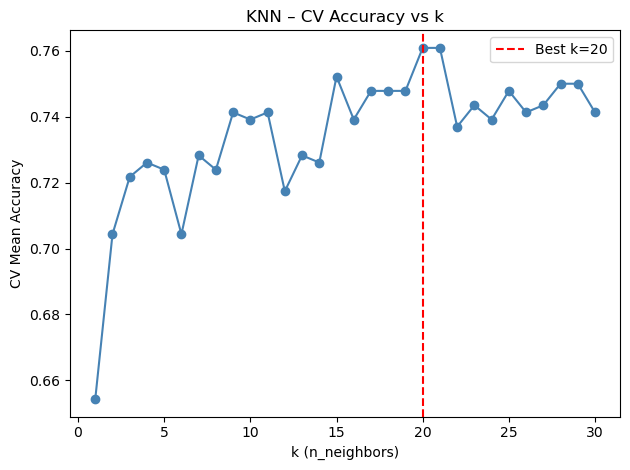

In [19]:
# Plot validation score vs k
k_values = list(param_grid_knn["n_neighbors"])
mean_scores = [grid_knn.cv_results_["mean_test_score"][i] for i in range(len(k_values))]

plt.plot(k_values, mean_scores, marker="o", color="steelblue")
plt.xlabel("k (n_neighbors)")
plt.ylabel("CV Mean Accuracy")
plt.title("KNN – CV Accuracy vs k")
plt.axvline(grid_knn.best_params_["n_neighbors"], color="red", linestyle="--",
            label=f'Best k={grid_knn.best_params_["n_neighbors"]}')
plt.legend()
plt.tight_layout()
plt.show()

## Section 7 – Logistic Regression

In [20]:
# Baseline Logistic Regression
lr_base = LogisticRegression(max_iter=2000, random_state=1138)
lr_base.fit(X_train, y_train)
print(f"Train accuracy : {lr_base.score(X_train, y_train):.4f}")
print(f"Valid accuracy : {lr_base.score(X_valid, y_valid):.4f}")

Train accuracy : 0.7674
Valid accuracy : 0.8117


In [21]:
# Grid search over regularisation strength C
param_grid_lr = {"C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=3000, random_state=1138),
                       param_grid=param_grid_lr, cv=5, verbose=1)
grid_lr.fit(X_train, y_train)
print("Best params :", grid_lr.best_params_)
print(f"CV best score  : {grid_lr.best_score_:.4f}")
print(f"Valid accuracy : {grid_lr.score(X_valid, y_valid):.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params : {'C': 10}
CV best score  : 0.7630
Valid accuracy : 0.8117


## Section 8 – Model Selection & Final Evaluation

Compare all tuned models on the **validation set**, pick the best one, retrain it on train + validation combined, then report performance on the **held-out test set** (used for the first and only time here).

In [22]:
# Collect validation accuracies for all tuned models
model_scores = {
    "SVC (tuned)"      : grid_svc.score(X_valid, y_valid),
    "Random Forest"    : grid_rf.score(X_valid, y_valid),
    "KNN (tuned)"      : grid_knn.score(X_valid, y_valid),
    "Logistic Reg."    : grid_lr.score(X_valid, y_valid),
}

score_df = pd.DataFrame.from_dict(model_scores, orient="index", columns=["Valid Accuracy"])
print(score_df.sort_values("Valid Accuracy", ascending=False).to_string())

best_model_name = max(model_scores, key=model_scores.get)
print(f"\n→ Best model: {best_model_name}  ({model_scores[best_model_name]:.4f})")

               Valid Accuracy
Logistic Reg.        0.811688
SVC (tuned)          0.798701
Random Forest        0.798701
KNN (tuned)          0.785714

→ Best model: Logistic Reg.  (0.8117)


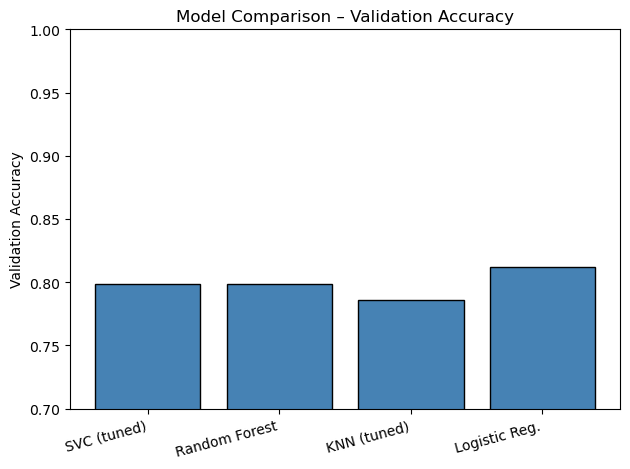

In [23]:
# Bar chart of model comparison
plt.bar(score_df.index, score_df["Valid Accuracy"], color="steelblue", edgecolor="black")
plt.ylim(0.7, 1.0)
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison – Validation Accuracy")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# Combine train + validation sets for final retraining
X_trainvalid = np.vstack((X_train, X_valid))
y_trainvalid = np.hstack((y_train, y_valid))

# Map name → grid object to retrieve best params
grid_lookup = {
    "SVC (tuned)"   : grid_svc,
    "Random Forest" : grid_rf,
    "KNN (tuned)"   : grid_knn,
    "Logistic Reg." : grid_lr,
}

best_grid = grid_lookup[best_model_name]
best_model = best_grid.best_estimator_.__class__(**best_grid.best_params_)

# Special case: ensure enough iterations for LR / random state where supported
if hasattr(best_model, "max_iter"):
    best_model.set_params(max_iter=3000)
if hasattr(best_model, "random_state"):
    best_model.set_params(random_state=1138)

best_model.fit(X_trainvalid, y_trainvalid)
print(f"Retrained {best_model_name} on train+valid ({X_trainvalid.shape[0]} samples)")

Retrained Logistic Reg. on train+valid (614 samples)


In [25]:
# Final test-set evaluation
test_acc = best_model.score(X_test, y_test)
print(f"Test accuracy ({best_model_name}): {test_acc:.4f}\n")

y_test_pred = best_model.predict(X_test)
cm = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, y_test_pred, target_names=["No Diabetes", "Diabetes"]))

Test accuracy (Logistic Reg.): 0.7597

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           91            9
Actual 1           28           26

              precision    recall  f1-score   support

 No Diabetes       0.76      0.91      0.83       100
    Diabetes       0.74      0.48      0.58        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.74       154



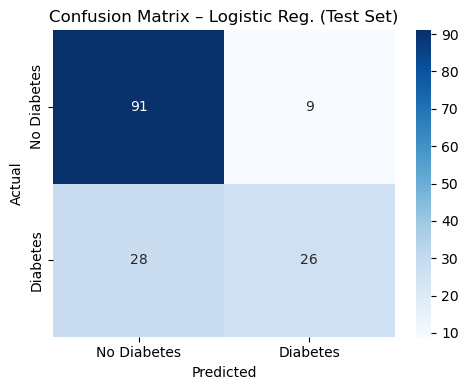

In [26]:
# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix – {best_model_name} (Test Set)")
plt.tight_layout()
plt.show()